In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving BX-Book-Ratings.csv to BX-Book-Ratings.csv
Saving BX-Books.csv to BX-Books.csv
Saving BX-Users.csv to BX-Users.csv


In [ ]:
books=pd.read_csv("BX-Books.csv",sep=";",encoding="latin-1,",on_bad_lines="skip")
ratings=pd.read_csv("BX-Book-Ratings.csv",sep=";",encoding="latin-1",on_bad_lines="skip")
users=pd.read_csv("BX-Users.csv",sep=";",encoding="latin-1",on_bad_lines="skip")
print("Books:",books.shape)
print("Ratings:",ratings.shape)
print("Users:",users.shape)

/tmp/ipykernel_5415/1448468237.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books=pd.read_csv("BX-Books.csv",sep=";",encoding="latin-1,",on_bad_lines="skip")


Books: (271360, 8)
Ratings: (1149780, 3)
Users: (278858, 3)


In [ ]:
books.columns=[
    'ISBN',
    'Book_Title',
    'Book_Author',
    'Year_Of_Publication',
    'Publisher',
    'Image_URL_S',
    'Image_URL_M',
    'Image_URL_L'
]
ratings.columns=[
    'User_ID',
    'ISBN',
    'Book_Rating'
]
users.columns=[
    'User_ID',
    'Location',
    'Age'
]

In [ ]:
book_ratings=ratings.merge(books[['ISBN','Book_Title']],on='ISBN')
book_ratings.head()

,User_ID,ISBN,Book_Rating,Book_Title
0,276725,034545104X,0,Flesh Tones: A Novel
1,276726,0155061224,5,Rites of Passage
2,276727,0446520802,0,The Notebook
3,276729,052165615X,3,Help!: Level 1
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...


In [ ]:
rating_count=book_ratings.groupby('Book_Title')['Book_Rating'].count().reset_index()
rating_count.rename(columns={'Book_Rating':'Num_Ratings'},inplace=True)
popular_books=rating_count[rating_count['Num_Ratings']>=50]
popular_books.head()

,Book_Title,Num_Ratings
203,10 Lb. Penalty,61
697,16 Lighthouse Road,65
764,1984,284
818,1st to Die: A Novel,509
946,2010: Odyssey Two,90


In [ ]:
filtered=book_ratings.merge(popular_books,on='Book_Title')
book_pivot=filtered.pivot_table(columns='User_ID',index='Book_Title',values='Book_Rating')
book_pivot.fillna(0,inplace=True)
book_pivot.head()

User_ID,8,9,14,16,17,19,23,26,32,39,...,278820,278824,278828,278832,278836,278843,278844,278846,278851,278854
Book_Title,,,,,,,,,,,,,,,,,,,,,
10 Lb. Penalty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16 Lighthouse Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010: Odyssey Two,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
similarity_scores=cosine_similarity(book_pivot)
print(similarity_scores.shape)

(2444, 2444)


In [ ]:
def recommend_books(book_name):
    if book_name not in book_pivot.index:
        print("Book not found")
        return
    index = np.where(
        book_pivot.index == book_name
    )[0][0]
    similar_items = sorted(
        list(enumerate(similarity_scores[index])),
        key=lambda x: x[1],
        reverse=True
    )[1:6]
    print(f"\nRecommended Books for '{book_name}':\n")
    for i in similar_items:
        print(book_pivot.index[i[0]])

# Example usage:
recommend_books('1984')


Recommended Books for '1984':

Animal Farm
Brave New World
American Psycho (Vintage Contemporaries)
Slaughterhouse Five or the Children's Crusade: A Duty Dance With Death
Lying Awake


In [ ]:
print(book_pivot.index[:20])

Index(['10 Lb. Penalty', '16 Lighthouse Road', '1984', '1st to Die: A Novel',
       '2010: Odyssey Two', '204 Rosewood Lane', '2061: Odyssey Three',
       '24 Hours', '2nd Chance', '3rd Degree', '4 Blondes',
       '50 Simple Things You Can Do to Save the Earth',
       '84 Charing Cross Road',
       'A 2nd Helping of Chicken Soup for the Soul (Chicken Soup for the Soul Series (Paper))',
       'A Beautiful Mind: The Life of Mathematical Genius and Nobel Laureate John Nash',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Clockwork Orange (Norton Paperback Fiction)'],
      dtype='object', name='Book_Title')


In [ ]:
recommend_books("The Lovely Bones:A Novel")

Book not found


In [ ]:
recommend_books("1984")


Recommended Books for '1984':

Animal Farm
Brave New World
American Psycho (Vintage Contemporaries)
Slaughterhouse Five or the Children's Crusade: A Duty Dance With Death
Lying Awake


In [ ]:
avg_similarity=np.mean(similarity_scores)
print(
    "Average Similarity Scores:",
    round(avg_similarity,4)
)

Average Similarity Scores: 0.0138


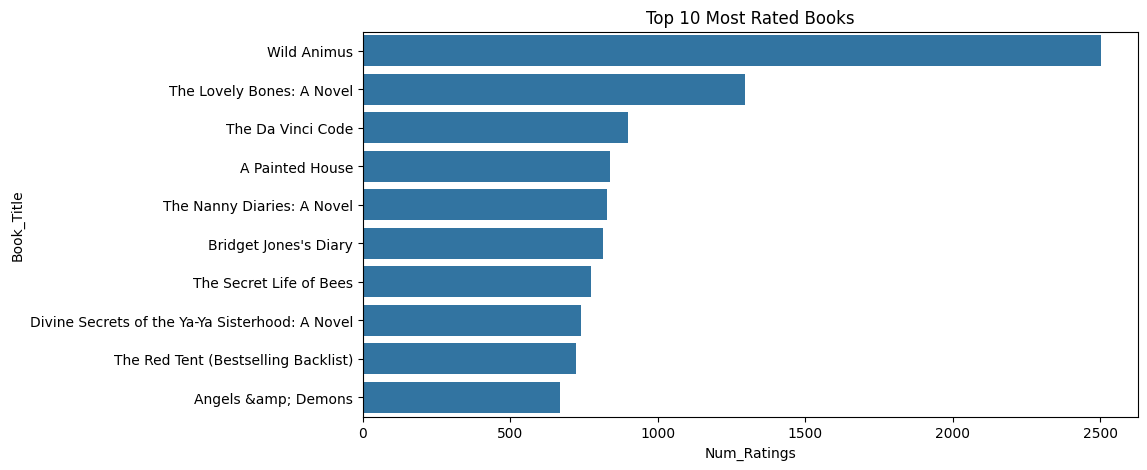

In [ ]:
top_books=rating_count.sort_values(
    'Num_Ratings',
    ascending=False
).head(10)
plt.figure(figsize=(10,5))
sns.barplot(
    x='Num_Ratings',
    y='Book_Title',
    data=top_books
)
plt.title("Top 10 Most Rated Books")
plt.show()